# Exercice 1.3 : Analyse du Réseau Marvel et Distributions de Degrés

Ce notebook contient l'analyse complète du réseau Marvel :
1. **Chargement du réseau Marvel** : Chargement des fichiers TSV (`week1_nodes.tsv` et `week1_edges.tsv`), graphe dirigé `G` et non dirigé `G_undir`, conservation des isolats.
2. **Distributions de degrés** : In-degree et Out-degree sur axes linéaires et log-log avec $(k+1)$ et top 5 des personnages.
3. **Système de Log-Binning** : Regroupement par intervalles croissants (largeur 1 puis doublement), moyenne géométrique et normalisation.
4. **Comparaison avec des modèles théoriques** : Distributions exponentielle et loi de puissance sur 4 combinaisons d'axes.

## 1. Chargement du réseau Marvel (`week1_nodes.tsv` et `week1_edges.tsv`)
- Chargement sous forme de graphe dirigé (`nx.DiGraph`) en insérant d'abord tous les nœuds depuis `nodes.node_id` pour préserver les 17 isolats.
- Vérification de la taille ($n = 303$ nœuds, $m = 1784$ arêtes dirigées).
- Transformation en graphe non dirigé ($m = 1434$, degré moyen $\langle k \rangle \approx 9.5$).

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# --- 1.1 Chargement des données TSV ---
nodes = pd.read_csv("week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: TSVs never quote, but blurbs may contain "quotes"
edges = pd.read_csv("week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

# --- 1.2 Construction du graphe dirigé ---
G = nx.DiGraph()
# Insertion des nœuds EN PREMIER pour conserver les 17 isolates
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))

n_nodes = G.number_of_nodes()
m_dir_edges = G.number_of_edges()
n_isolates = len(list(nx.isolates(G)))

print("=== 1. Graphe Dirigé Marvel (G) ===")
print(f"• Nombre de nœuds (n)          : {n_nodes} (attendu : 303)")
print(f"• Nombre d'arêtes dirigées (m) : {m_dir_edges} (attendu : 1784)")
print(f"• Nombre d'isolates (degré 0)  : {n_isolates} (attendu : 17)")

# --- 1.3 Transformation en graphe non dirigé ---
G_undir = G.to_undirected()
m_undir_edges = G_undir.number_of_edges()
avg_degree = 2 * m_undir_edges / n_nodes

print("\n=== 2. Graphe Non-Dirigé Marvel (G_undir) ===")
print(f"• Nombre d'arêtes non dirigées (m) : {m_undir_edges} (attendu : 1434)")
print(f"• Degré moyen (<k>)                : {avg_degree:.2f} (attendu : ~9.5)")

# Commentaire explicatif (en une phrase) :
# Le nombre d'arêtes dirigées (1 784) et non dirigées (1 434) diffère car les liens réciproques (u -> v et v -> u) fusionnent en une seule arête non orientée {u, v} lors de la conversion.

=== 1. Graphe Dirigé Marvel (G) ===
• Nombre de nœuds (n)          : 303 (attendu : 303)
• Nombre d'arêtes dirigées (m) : 1784 (attendu : 1784)
• Nombre d'isolates (degré 0)  : 17 (attendu : 17)

=== 2. Graphe Non-Dirigé Marvel (G_undir) ===
• Nombre d'arêtes non dirigées (m) : 1434 (attendu : 1434)
• Degré moyen (<k>)                : 9.47 (attendu : ~9.5)


## 2. Distributions de degrés (In-degree et Out-degree)
- Tracé des distributions en échelles linéaire et log-log.
- Utilisation de $(k + 1)$ pour inclure les 17 isolats ($k=0$) sur l'échelle logarithmique.
- Affichage des 5 personnages ayant les plus hauts degrés pour chaque distribution.

=== TOP 5 PERSONNAGES - IN-DEGREE (les plus mentionnés / cibles) ===
1. ID: Spider-Man | Nom: Spider-Man                   | in-degree = 106
2. ID: Hulk   | Nom: Hulk                         | in-degree = 64
3. ID: Wolverine_(character) | Nom: Wolverine (character)        | in-degree = 60
4. ID: Doctor_Strange | Nom: Doctor Strange               | in-degree = 50
5. ID: Deadpool | Nom: Deadpool                     | in-degree = 33

=== TOP 5 PERSONNAGES - OUT-DEGREE (les plus actifs / sources) ===
1. ID: Betsy_Braddock | Nom: Betsy Braddock               | out-degree = 28
2. ID: Cloak_and_Dagger_(characters) | Nom: Cloak and Dagger (characters) | out-degree = 24
3. ID: Adam_Warlock | Nom: Adam Warlock                 | out-degree = 22
4. ID: Venom_(character) | Nom: Venom (character)            | out-degree = 21
5. ID: She-Hulk | Nom: She-Hulk                     | out-degree = 20


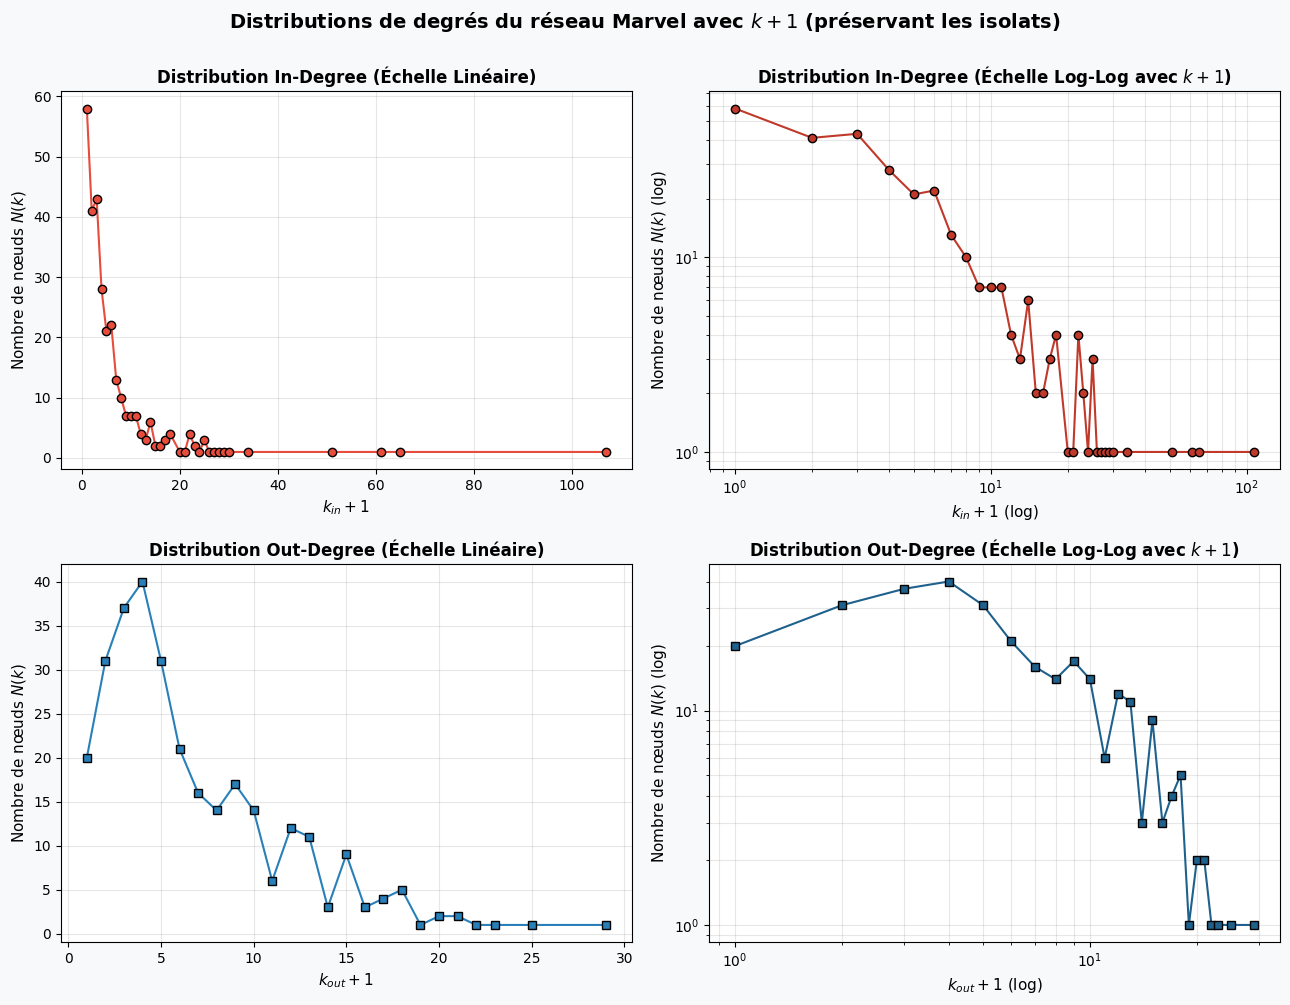

In [3]:
# Mapping facultatif des noms de personnages si une colonne nom existe
name_cols = [col for col in nodes.columns if col.lower() in ['name', 'label', 'character', 'hero']]
id_to_name = dict(zip(nodes.node_id, nodes[name_cols[0]])) if name_cols else {nid: nid for nid in nodes.node_id}

# Extraction des degrés entrants et sortants
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Top 5 personnages pour In-degree et Out-degree
top5_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
top5_out = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]

print("=== TOP 5 PERSONNAGES - IN-DEGREE (les plus mentionnés / cibles) ===")
for rank, (char_id, deg) in enumerate(top5_in, 1):
    name_str = id_to_name.get(char_id, char_id)
    print(f"{rank}. ID: {char_id:<6} | Nom: {name_str:<28} | in-degree = {deg}")

print("\n=== TOP 5 PERSONNAGES - OUT-DEGREE (les plus actifs / sources) ===")
for rank, (char_id, deg) in enumerate(top5_out, 1):
    name_str = id_to_name.get(char_id, char_id)
    print(f"{rank}. ID: {char_id:<6} | Nom: {name_str:<28} | out-degree = {deg}")

# Comptages des distributions avec (k + 1)
in_deg_vals = np.array(list(in_degrees.values()))
out_deg_vals = np.array(list(out_degrees.values()))

in_counter = Counter(in_deg_vals + 1)     # k_in + 1
out_counter = Counter(out_deg_vals + 1)   # k_out + 1

k_in_sorted = sorted(in_counter.keys())
cnt_in = [in_counter[k] for k in k_in_sorted]

k_out_sorted = sorted(out_counter.keys())
cnt_out = [out_counter[k] for k in k_out_sorted]

# --- Tracé des distributions (2x2 : In-degree et Out-degree sur Lin & Log-Log) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10), facecolor='#f8f9fa')

# 1. In-Degree - Linéaire
axes[0, 0].plot(k_in_sorted, cnt_in, 'o-', color='#e74c3c', markeredgecolor='black', lw=1.5, ms=6)
axes[0, 0].set_title("Distribution In-Degree (Échelle Linéaire)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("$k_{in} + 1$", fontsize=11)
axes[0, 0].set_ylabel("Nombre de nœuds $N(k)$", fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. In-Degree - Log-Log
axes[0, 1].loglog(k_in_sorted, cnt_in, 'o-', color='#c0392b', markeredgecolor='black', lw=1.5, ms=6)
axes[0, 1].set_title("Distribution In-Degree (Échelle Log-Log avec $k+1$)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("$k_{in} + 1$ (log)", fontsize=11)
axes[0, 1].set_ylabel("Nombre de nœuds $N(k)$ (log)", fontsize=11)
axes[0, 1].grid(True, which='both', alpha=0.3)

# 3. Out-Degree - Linéaire
axes[1, 0].plot(k_out_sorted, cnt_out, 's-', color='#2980b9', markeredgecolor='black', lw=1.5, ms=6)
axes[1, 0].set_title("Distribution Out-Degree (Échelle Linéaire)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("$k_{out} + 1$", fontsize=11)
axes[1, 0].set_ylabel("Nombre de nœuds $N(k)$", fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Out-Degree - Log-Log
axes[1, 1].loglog(k_out_sorted, cnt_out, 's-', color='#1f618d', markeredgecolor='black', lw=1.5, ms=6)
axes[1, 1].set_title("Distribution Out-Degree (Échelle Log-Log avec $k+1$)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("$k_{out} + 1$ (log)", fontsize=11)
axes[1, 1].set_ylabel("Nombre de nœuds $N(k)$ (log)", fontsize=11)
axes[1, 1].grid(True, which='both', alpha=0.3)

plt.suptitle("Distributions de degrés du réseau Marvel avec $k+1$ (préservant les isolats)", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 3. Implémentation du Système de Log-Binning
- Largeur de 1 pour $(k+1)$ de 1 à 7 : $[1, 2), [2, 3), \dots, [7, 8)$
- Largeur qui double ensuite : $[8, 16), [16, 32), [32, 64), [64, 128), \dots$
- Normalisation de chaque compte par la largeur du bin : $y_i = \frac{N_i}{\Delta k_i}$
- Position $x$ placée à la moyenne géométrique des bornes du bin : $x_i = \sqrt{b_i \cdot b_{i+1}}$
- Superposition sur les points bruts pour vérifier la coïncidence parfaite sur les bins de largeur 1.

=== DÉTAILS DU LOG-BINNING (In-Degree + 1) ===
Intervalle    Largeur   Compte brut   Moyenne géo (x)   Compte normalisé (y)
[1, 2)        1         58            1.41              58.000              
[2, 3)        1         41            2.45              41.000              
[3, 4)        1         43            3.46              43.000              
[4, 5)        1         28            4.47              28.000              
[5, 6)        1         21            5.48              21.000              
[6, 7)        1         22            6.48              22.000              
[7, 8)        1         13            7.48              13.000              
[8, 16)       8         46            11.31             5.750               
[16, 32)      16        26            22.63             1.625               
[32, 64)      32        3             45.25             0.094               
[64, 128)     64        2             90.51             0.031               


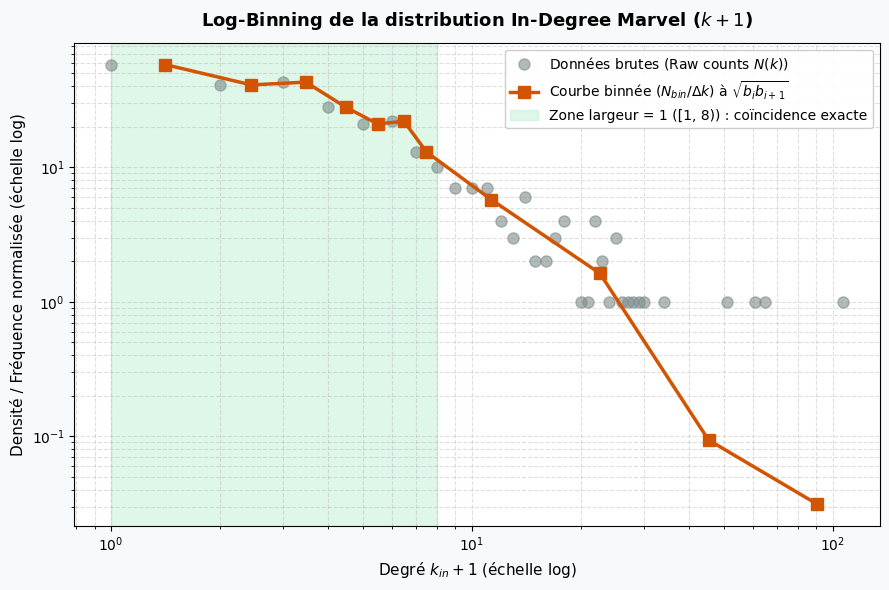

In [5]:
def apply_custom_binning(degrees_plus_1):
    """
    Applique le système de binning spécifique :
    - largeur 1 pour k+1 dans [1, 7]
    - intervalles doublants au-delà de 8 : [8, 16), [16, 32), etc.
    """
    max_val = max(degrees_plus_1) + 2
    
    # Construction des bornes de bins
    bin_edges = [1, 2, 3, 4, 5, 6, 7, 8]
    current_edge = 8
    while current_edge < max_val:
        current_edge *= 2
        bin_edges.append(current_edge)
    
    binned_x = []
    binned_y = []
    bin_info = []
    
    for i in range(len(bin_edges) - 1):
        low = bin_edges[i]
        high = bin_edges[i+1]
        width = high - low
        
        # Nœuds tombant dans l'intervalle [low, high)
        count = np.sum((degrees_plus_1 >= low) & (degrees_plus_1 < high))
        
        if count > 0:
            # Moyenne géométrique des bornes du bin
            geom_mean = np.sqrt(low * high)
            normalized_count = count / width
            
            binned_x.append(geom_mean)
            binned_y.append(normalized_count)
            bin_info.append((f"[{low}, {high})", width, count, geom_mean, normalized_count))
            
    return np.array(binned_x), np.array(binned_y), bin_info

# Application sur In-Degree (k + 1)
in_deg_p1 = in_deg_vals + 1
binned_x, binned_y, bin_info = apply_custom_binning(in_deg_p1)

# Données brutes
raw_counter = Counter(in_deg_p1)
raw_x = np.array(sorted(raw_counter.keys()))
raw_y = np.array([raw_counter[k] for k in raw_x])

# Tableau récapitulatif des bins
print("=== DÉTAILS DU LOG-BINNING (In-Degree + 1) ===")
print(f"{'Intervalle':<14}{'Largeur':<10}{'Compte brut':<14}{'Moyenne géo (x)':<18}{'Compte normalisé (y)':<20}")
for interval, w, c, gx, ny in bin_info:
    print(f"{interval:<14}{w:<10}{c:<14}{gx:<18.2f}{ny:<20.3f}")

# --- Graphique de comparaison : Données brutes vs Courbe binnée ---
plt.figure(figsize=(9, 6), facecolor='#f8f9fa')

# 1. Points bruts
plt.loglog(raw_x, raw_y, 'o', color='#7f8c8d', alpha=0.6, markersize=8, label='Données brutes (Raw counts $N(k)$)')

# 2. Courbe binnée
plt.loglog(binned_x, binned_y, 's-', color='#d35400', linewidth=2.5, markersize=8, label='Courbe binnée ($N_{bin} / \Delta k$) à $\sqrt{b_i b_{i+1}}$')

# Mise en évidence de la zone où la largeur vaut 1
plt.axvspan(1, 8, color='#2ecc71', alpha=0.15, label='Zone largeur = 1 ([1, 8)) : coïncidence exacte')

plt.title("Log-Binning de la distribution In-Degree Marvel ($k+1$)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Degré $k_{in} + 1$ (échelle log)", fontsize=11)
plt.ylabel("Densité / Fréquence normalisée (échelle log)", fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=10)
plt.tight_layout()
plt.show()

## 4. Comparaison avec les Modèles Théoriques (Exponentielle vs Loi de Puissance)
- Génération de 10 000 échantillons d'une distribution exponentielle et 10 000 d'une loi de puissance (Power Law).
- Visualisation sur les 4 combinaisons d'axes possibles :
  1. **Linéaire - Linéaire** : Vue standard
  2. **LogX - LinY (Semilog-X)** : Non-linéaire pour les deux
  3. **LinX - LogY (Semilog-Y)** : **Redresse la distribution Exponentielle** ($y \sim e^{-\lambda x} \implies \ln(y) \sim -\lambda x$)
  4. **LogX - LogY (Log-Log)** : **Redresse la Loi de Puissance** ($y \sim x^{-\gamma} \implies \ln(y) \sim -\gamma \ln(x)$)
- Superposition de la vraie distribution In-Degree Marvel sur ces 4 axes.

/var/folders/l4/73ptxpgs2wdc8fc897bh461c0000gn/T/ipykernel_9674/722412626.py:50: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/romeosofia/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


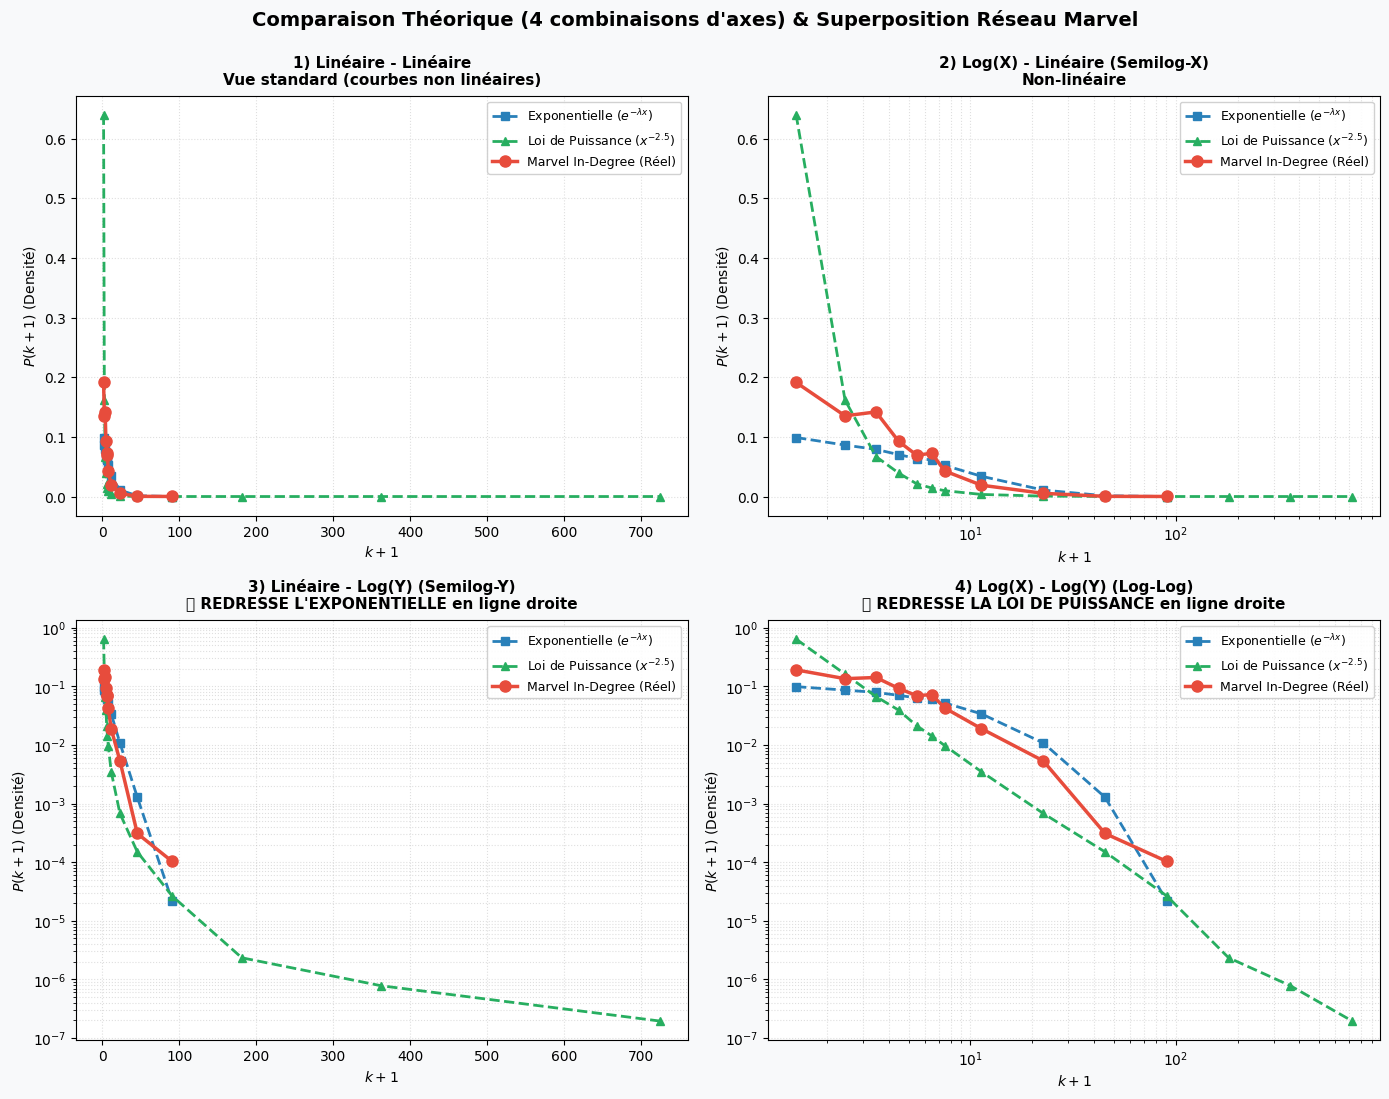

=== ANALYSE COMPARATIVE ===
1. Semilog-Y (Linéaire en X, Log en Y) : Redresse la distribution exponentielle en une droite décroissante de pente -lambda.
2. Log-Log (Log en X, Log en Y) : Redresse la loi de puissance (Power Law) en une droite décroissante de pente -gamma.
3. Réseau Marvel : En log-log, la distribution présente un profil linéaire caractéristique d'une loi de puissance (Scale-Free) sur plusieurs ordres de grandeur avant une chute due à la taille finie.


In [6]:
# Fixer la graine pour reproductibilité
np.random.seed(42)
n_samples = 10000

# 1. Génération des distributions synthétiques
# Distribution Exponentielle
exp_data = np.random.exponential(scale=10.0, size=n_samples) + 1

# Loi de Puissance (Power Law : x_min=1, gamma=2.5)
gamma = 2.5
u = np.random.uniform(0, 1, size=n_samples)
powerlaw_data = (1.0 - u) ** (-1.0 / (gamma - 1.0))

# Binnings respectifs
bx_exp, by_exp, _ = apply_custom_binning(exp_data)
bx_pl, by_pl, _ = apply_custom_binning(powerlaw_data)

# Normalisation des probabilités (densités de probabilité P(x))
by_exp_pdf = by_exp / n_samples
by_pl_pdf = by_pl / n_samples
by_marvel_pdf = binned_y / len(in_deg_p1)

# --- Tracé sur les 4 combinaisons d'axes ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), facecolor='#f8f9fa')

configs = [
    (axes[0, 0], 'linear', 'linear', "1) Linéaire - Linéaire", "Vue standard (courbes non linéaires)"),
    (axes[0, 1], 'log', 'linear', "2) Log(X) - Linéaire (Semilog-X)", "Non-linéaire"),
    (axes[1, 0], 'linear', 'log', "3) Linéaire - Log(Y) (Semilog-Y)", "⭐ REDRESSE L'EXPONENTIELLE en ligne droite"),
    (axes[1, 1], 'log', 'log', "4) Log(X) - Log(Y) (Log-Log)", "⭐ REDRESSE LA LOI DE PUISSANCE en ligne droite")
]

for ax, xscale, yscale, title, subtitle in configs:
    # Exponentielle
    ax.plot(bx_exp, by_exp_pdf, 's--', color='#2980b9', lw=2, ms=6, label='Exponentielle ($e^{-\lambda x}$)')
    # Power Law
    ax.plot(bx_pl, by_pl_pdf, '^--', color='#27ae60', lw=2, ms=6, label=f'Loi de Puissance ($x^{{-{gamma}}}$)')
    # Réseau Marvel (In-degree)
    ax.plot(binned_x, by_marvel_pdf, 'o-', color='#e74c3c', lw=2.5, ms=8, label='Marvel In-Degree (Réel)')
    
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_title(f"{title}\n{subtitle}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel("$k + 1$", fontsize=10)
    ax.set_ylabel("$P(k+1)$ (Densité)", fontsize=10)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.suptitle("Comparaison Théorique (4 combinaisons d'axes) & Superposition Réseau Marvel", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("=== ANALYSE COMPARATIVE ===")
print("1. Semilog-Y (Linéaire en X, Log en Y) : Redresse la distribution exponentielle en une droite décroissante de pente -lambda.")
print("2. Log-Log (Log en X, Log en Y) : Redresse la loi de puissance (Power Law) en une droite décroissante de pente -gamma.")
print("3. Réseau Marvel : En log-log, la distribution présente un profil linéaire caractéristique d'une loi de puissance (Scale-Free) sur plusieurs ordres de grandeur avant une chute due à la taille finie.")